In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,OrdinalEncoder,StandardScaler,MinMaxScaler


In [2]:
data=pd.read_excel(r'E:\credit_risk_modeling\data\case_study1.xlsx')
df=data.copy()
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32


In [3]:
data1=pd.read_excel(r'E:\credit_risk_modeling\data\case_study2.xlsx')
df1=data1.copy()
df1.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [4]:
print("shape of df:", df.shape)
print("shape of df1:", df1.shape)



shape of df: (51336, 26)
shape of df1: (51336, 62)


In [5]:
df.describe()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,...,0.124981,1.136084,1.561847,0.070146,0.282511,2.844904,2.013694,1.089762,-32.575639,-62.149525
std,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,...,0.505201,2.227997,5.376434,0.340861,0.858168,6.187177,3.198322,2.417496,2791.869609,2790.818622
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000
25%,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000
50%,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,33.000000,8.000000
75%,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,...,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,1.000000,64.000000,17.000000
max,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,...,27.000000,41.000000,235.000000,10.000000,29.000000,235.000000,55.000000,80.000000,392.000000,392.000000


In [6]:
df1.describe()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25668.500000,-8129.961314,-70020.091320,-70022.375838,1.573749,-70003.987085,13.521953,0.184977,0.480053,0.295076,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,27749.328514,45823.312757,45819.820741,4.165012,45847.976100,53.336976,0.710240,1.522210,1.027471,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,1.000000,-99999.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12834.750000,46.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25668.500000,70.000000,-99999.000000,-99999.000000,0.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38502.250000,161.000000,8.000000,3.000000,1.000000,15.000000,10.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51336.000000,6065.000000,35.000000,35.000000,74.000000,900.000000,900.000000,12.000000,28.000000,20.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [9]:
df[df.duplicated()]

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL


In [10]:
df1[df1.duplicated(keep=False)]

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag


In [11]:
df.isnull().sum()/len(df)

PROSPECTID              0.0
Total_TL                0.0
Tot_Closed_TL           0.0
Tot_Active_TL           0.0
Total_TL_opened_L6M     0.0
Tot_TL_closed_L6M       0.0
pct_tl_open_L6M         0.0
pct_tl_closed_L6M       0.0
pct_active_tl           0.0
pct_closed_tl           0.0
Total_TL_opened_L12M    0.0
Tot_TL_closed_L12M      0.0
pct_tl_open_L12M        0.0
pct_tl_closed_L12M      0.0
Tot_Missed_Pmnt         0.0
Auto_TL                 0.0
CC_TL                   0.0
Consumer_TL             0.0
Gold_TL                 0.0
Home_TL                 0.0
PL_TL                   0.0
Secured_TL              0.0
Unsecured_TL            0.0
Other_TL                0.0
Age_Oldest_TL           0.0
Age_Newest_TL           0.0
dtype: float64

<Axes: >

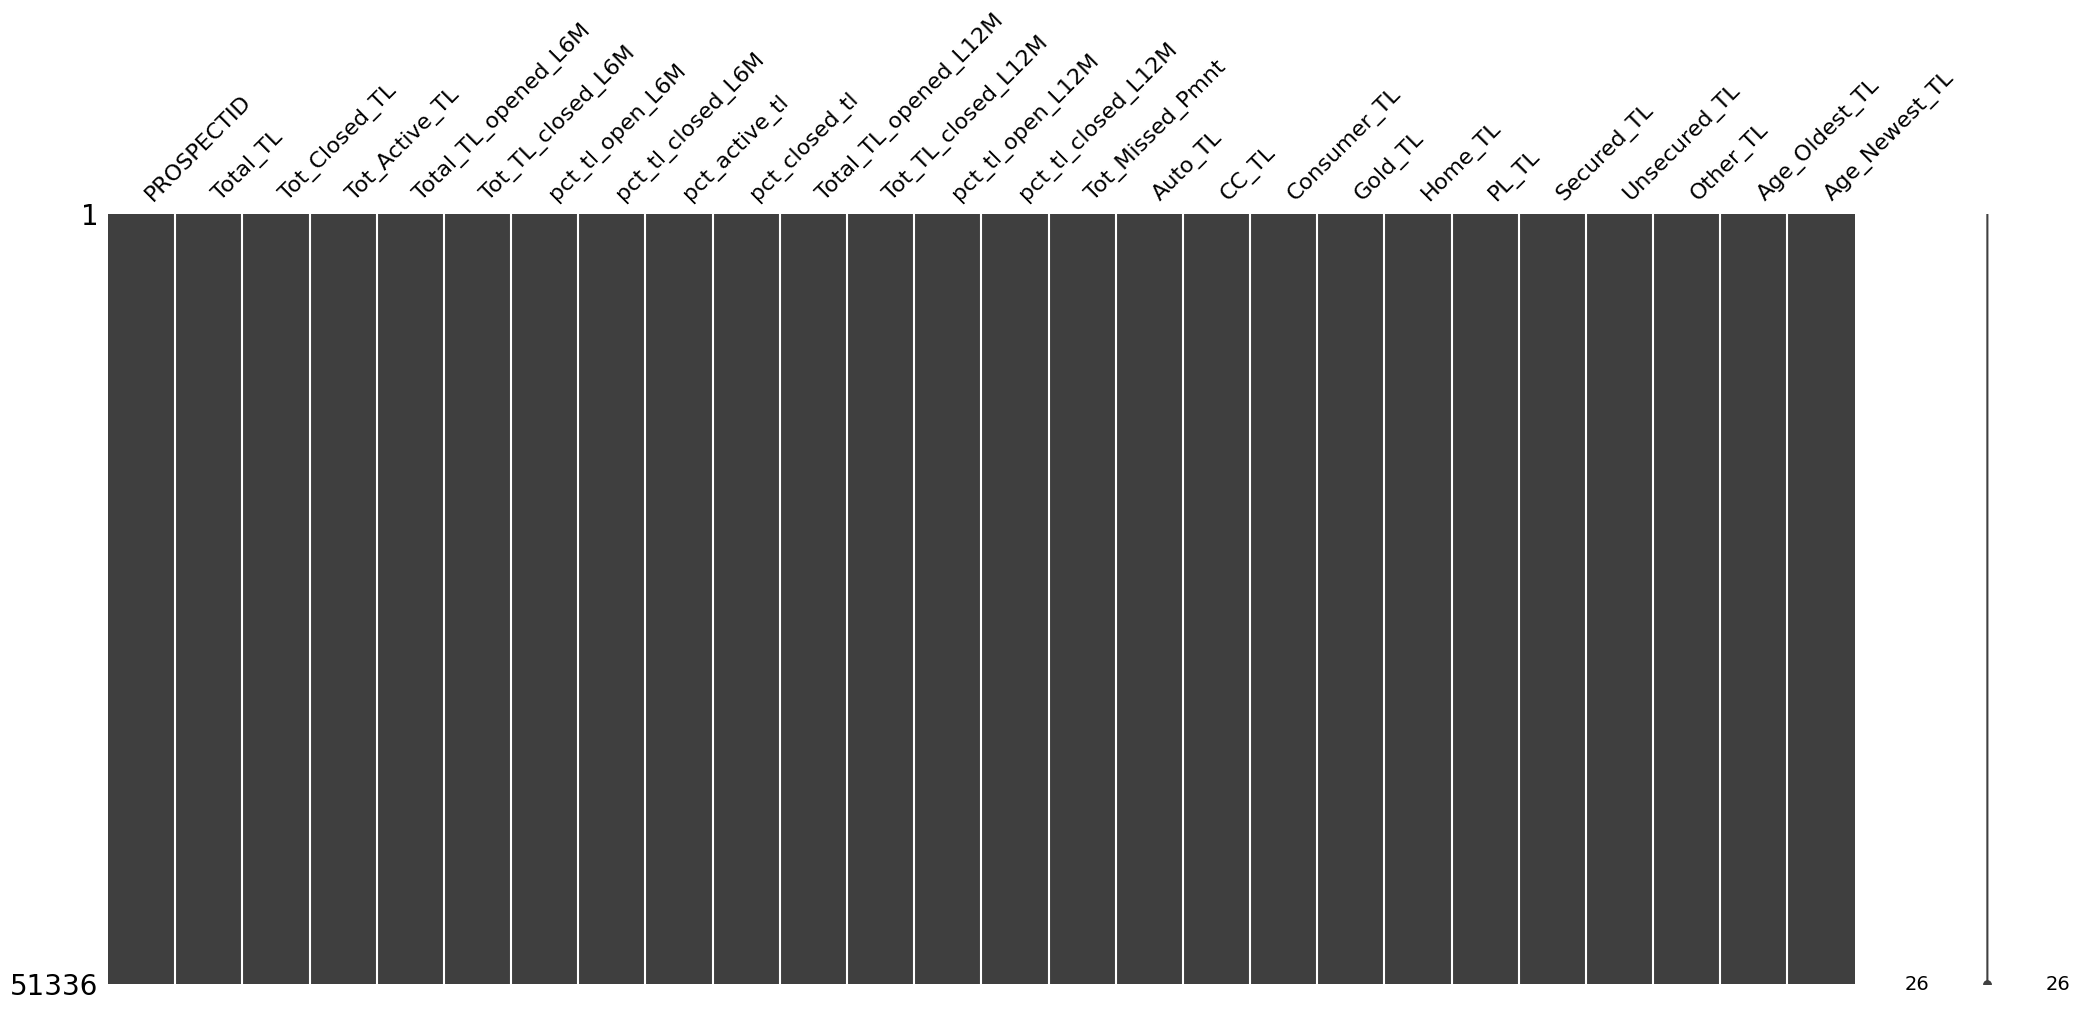

In [12]:
msno.matrix(df)

In [13]:
df1.isnull().sum()/len(df1)

PROSPECTID                      0.0
time_since_recent_payment       0.0
time_since_first_deliquency     0.0
time_since_recent_deliquency    0.0
num_times_delinquent            0.0
                               ... 
GL_Flag                         0.0
last_prod_enq2                  0.0
first_prod_enq2                 0.0
Credit_Score                    0.0
Approved_Flag                   0.0
Length: 62, dtype: float64

<Axes: >

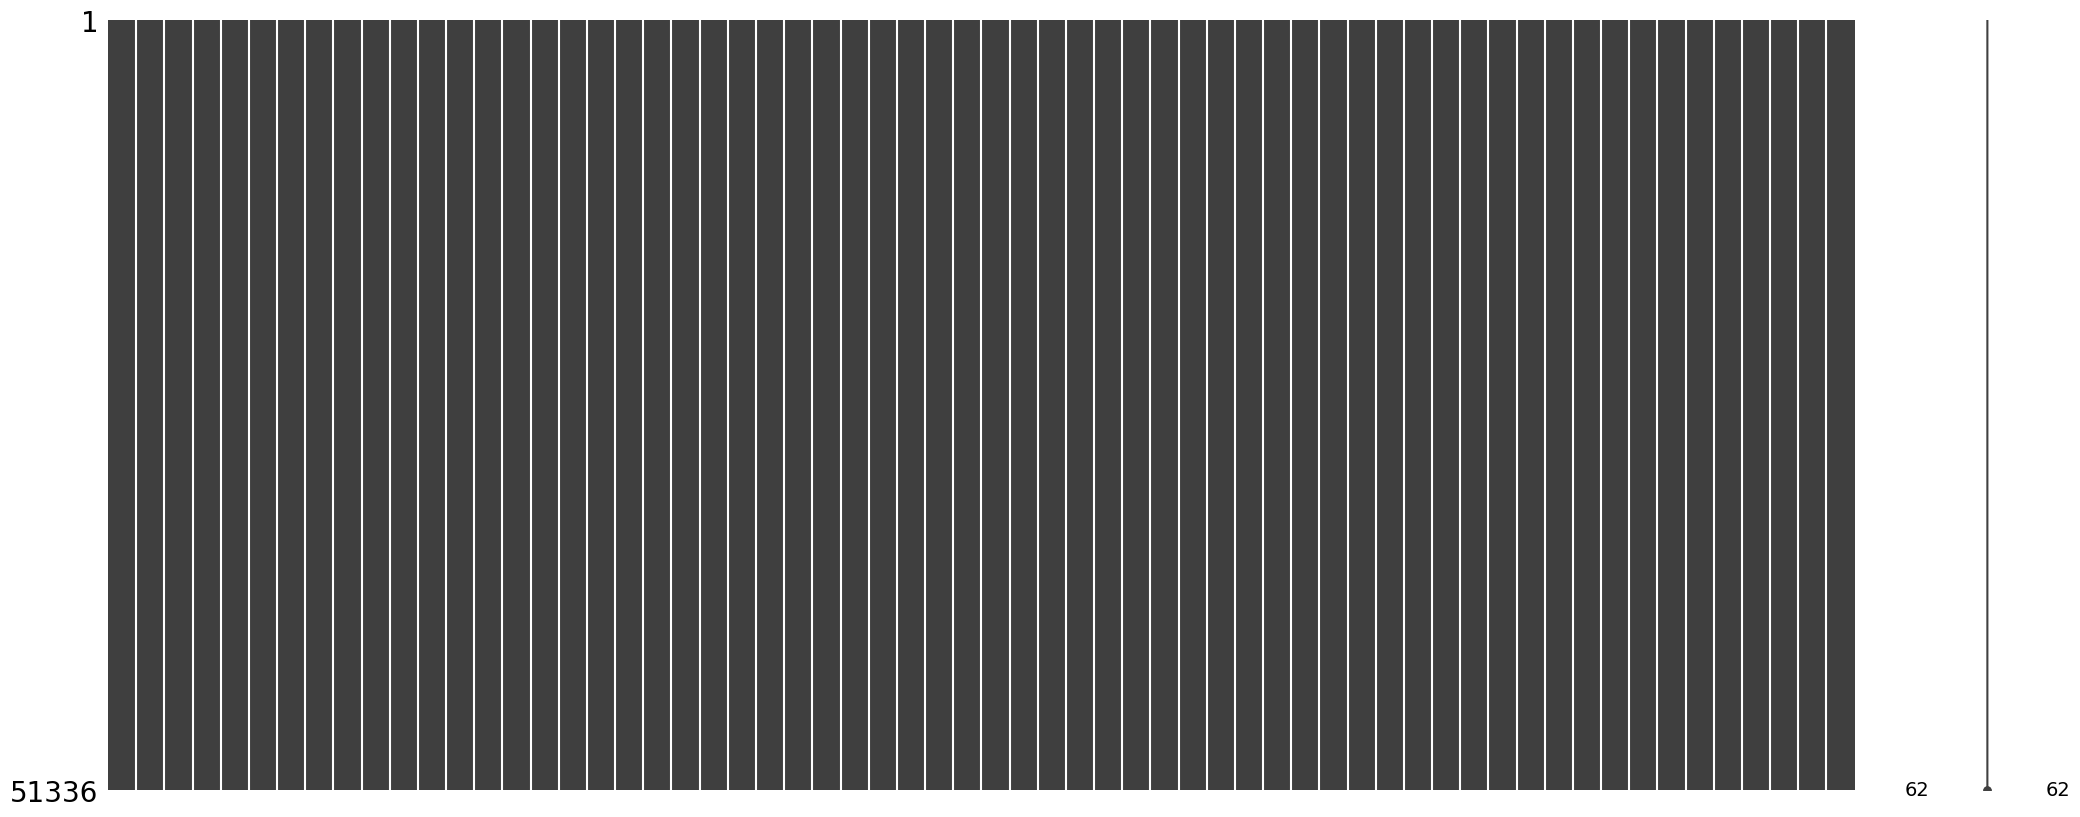

In [14]:
msno.matrix(df1)

# categorical columns

In [15]:
print("object columns in df:", df.select_dtypes(include='object').columns.tolist())
print("object columns in df1:", df1.select_dtypes(include='object').columns.tolist())   

object columns in df: []
object columns in df1: ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


# numerical columns

In [16]:
print("numerical columns in df:", df.select_dtypes(include=np.number).columns.tolist())
print("numerical columns in df1:", df1.select_dtypes(include=np.number).columns.tolist())   

numerical columns in df: ['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL']
numerical columns in df1: ['PROSPECTID', 'time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'num_times_delinquent', 'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq'

In [17]:
for i in df1.select_dtypes(include='object').columns:
    print(f"Unique values in column '{i}':")
    print(df1[i].unique())
    print("\n")

Unique values in column 'MARITALSTATUS':
['Married' 'Single']


Unique values in column 'EDUCATION':
['12TH' 'GRADUATE' 'SSC' 'POST-GRADUATE' 'UNDER GRADUATE' 'OTHERS'
 'PROFESSIONAL']


Unique values in column 'GENDER':
['M' 'F']


Unique values in column 'last_prod_enq2':
['PL' 'ConsumerLoan' 'others' 'AL' 'CC' 'HL']


Unique values in column 'first_prod_enq2':
['PL' 'ConsumerLoan' 'others' 'AL' 'HL' 'CC']


Unique values in column 'Approved_Flag':
['P2' 'P1' 'P3' 'P4']




In [18]:
for i in df1.select_dtypes(include='object').columns:
    print(f" value counts in column '{i}':")
    print(df1[i].value_counts())
    print("\n")

 value counts in column 'MARITALSTATUS':
MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64


 value counts in column 'EDUCATION':
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64


 value counts in column 'GENDER':
GENDER
M    45245
F     6091
Name: count, dtype: int64


 value counts in column 'last_prod_enq2':
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64


 value counts in column 'first_prod_enq2':
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64


 value counts in column 'Approved_Flag':
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: coun

<Axes: xlabel='Approved_Flag', ylabel='count'>

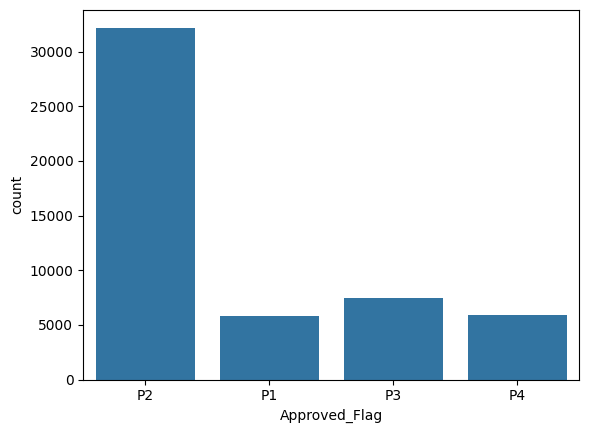

In [19]:

sns.countplot(x='Approved_Flag', data=df1)

# observation 1


In [20]:
# shape of df: (51336, 26)
# shape of df1: (51336, 62)

# df has not object columns
# df1 has 6 object column: ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']

# no duplicates in both df and df1
# no missing values in both df and df1

# no inconsistent values in object columns of df1
# Approved_Flag has 4 classes:
                #  P2    32199
                #  P3     7452
                #  P4     5882
                #  P1     5803


# Data cleaning

even thought we dont find missing values in both data frame in banking sector null values are represented in terms of  -99999
(-99999) is called a sentinel value (or placeholder), used instead of real nulls.

In [21]:
# Remove nulls from df
df = df.loc[df['Age_Oldest_TL'] != -99999]


colums with high null values removed for model performance

In [22]:
columns_to_be_removed = []

for i in df1.columns:
    if df1.loc[df1[i] == -99999].shape[0] > 10000:
        columns_to_be_removed .append(i)
print("Columns to be removed from df1:", columns_to_be_removed)

Columns to be removed from df1: ['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']


In [ ]:
for i in df1.columns:
    if df1.loc[df1[i] == -99999].shape[0] > 10000:
        columns_to_be_removed .append(i)
print("Columns to be removed from df1:", columns_to_be_removed)
df = df.loc[df['Age_Oldest_TL'] != -99999]

In [23]:
df1 = df1.drop(columns_to_be_removed, axis =1)


In [24]:
for i in df1.columns:
    df1 = df1.loc[ df1[i] != -99999 ]

In [25]:
print("shape of df after removing nulls:", df.shape)
print("shape of df1 after removing nulls:", df1.shape)

shape of df after removing nulls: (51296, 26)
shape of df1 after removing nulls: (42066, 54)


In [26]:
# Checking common column names
for i in list(df.columns):
    if i in list(df1.columns):
        print(i)

PROSPECTID


In [27]:
# Merge the two dataframes, inner join so that no nulls are present
df_final = pd. merge ( df, df1, how ='inner', left_on = ['PROSPECTID'], right_on = ['PROSPECTID'] )

In [28]:
df_final.shape

(42064, 79)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51296 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51296 non-null  int64  
 1   Total_TL              51296 non-null  int64  
 2   Tot_Closed_TL         51296 non-null  int64  
 3   Tot_Active_TL         51296 non-null  int64  
 4   Total_TL_opened_L6M   51296 non-null  int64  
 5   Tot_TL_closed_L6M     51296 non-null  int64  
 6   pct_tl_open_L6M       51296 non-null  float64
 7   pct_tl_closed_L6M     51296 non-null  float64
 8   pct_active_tl         51296 non-null  float64
 9   pct_closed_tl         51296 non-null  float64
 10  Total_TL_opened_L12M  51296 non-null  int64  
 11  Tot_TL_closed_L12M    51296 non-null  int64  
 12  pct_tl_open_L12M      51296 non-null  float64
 13  pct_tl_closed_L12M    51296 non-null  float64
 14  Tot_Missed_Pmnt       51296 non-null  int64  
 15  Auto_TL               51

In [30]:
df_final[df_final.duplicated()]

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag


In [31]:
df_final["Approved_Flag"].value_counts()

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64

In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   Total_TL                      51336 non-null  int64  
 2   Tot_Closed_TL                 51336 non-null  int64  
 3   Tot_Active_TL                 51336 non-null  int64  
 4   Total_TL_opened_L6M           51336 non-null  int64  
 5   Tot_TL_closed_L6M             51336 non-null  int64  
 6   pct_tl_open_L6M               51336 non-null  float64
 7   pct_tl_closed_L6M             51336 non-null  float64
 8   pct_active_tl                 51336 non-null  float64
 9   pct_closed_tl                 51336 non-null  float64
 10  Total_TL_opened_L12M          51336 non-null  int64  
 11  Tot_TL_closed_L12M            51336 non-null  int64  
 12  pct_tl_open_L12M              51336 non-null  float64
 13  p

# observation2

In [32]:
# final dataset info
      # dataframes has (42064 rows, 79 columns)
      # no nulls, no duplicates, no inconsistent values in object columns
      # Approved_Flag has 4 classes:
                #  P2    25452
                # P3     6440
                # P4     5264
                 # P1     4908

       # categorical columns: ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']
       # numerical columns: all other columns except the above categorical columns and PROSPECTID


# Data Visualization of categorical values

C:\Users\User\AppData\Local\Temp\ipykernel_16348\2150180024.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="MARITALSTATUS", data=df_final, ax=axes[0, 0], palette=palettes[0])
C:\Users\User\AppData\Local\Temp\ipykernel_16348\2150180024.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="EDUCATION", data=df_final, ax=axes[0, 1], palette=palettes[1])
C:\Users\User\AppData\Local\Temp\ipykernel_16348\2150180024.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="GENDER", data=df_final, ax=axes[1, 0], palette=palettes[2])
C:\

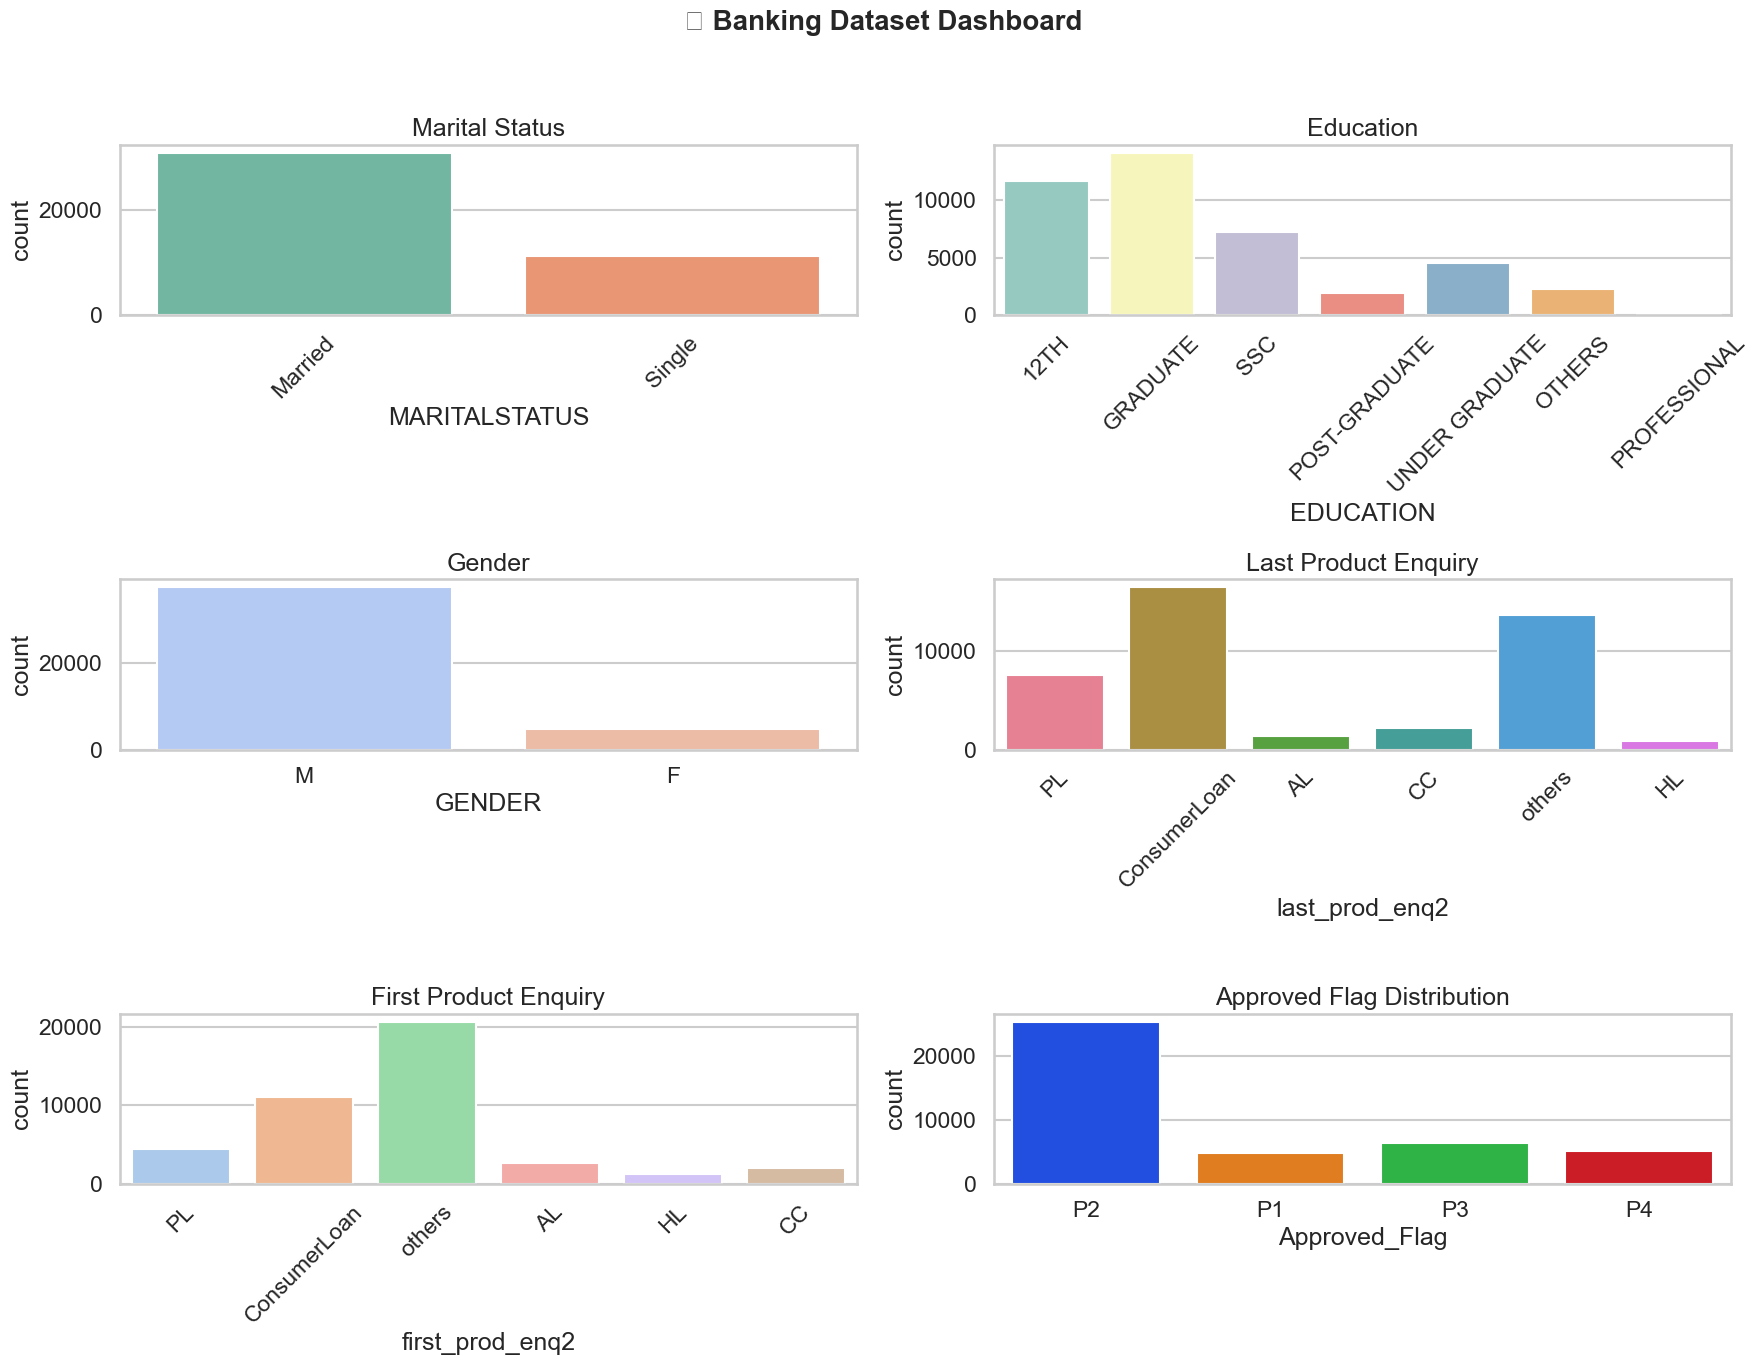

In [33]:
sns.set_style("whitegrid")
sns.set_context("talk")  

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle("🌈 Banking Dataset Dashboard", fontsize=20, fontweight='bold')


palettes = ["Set2", "Set3", "coolwarm", "husl", "pastel", "bright"]

sns.countplot(x="MARITALSTATUS", data=df_final, ax=axes[0, 0], palette=palettes[0])
axes[0, 0].set_title("Marital Status")
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(x="EDUCATION", data=df_final, ax=axes[0, 1], palette=palettes[1])
axes[0, 1].set_title("Education")
axes[0, 1].tick_params(axis='x', rotation=45)


sns.countplot(x="GENDER", data=df_final, ax=axes[1, 0], palette=palettes[2])
axes[1, 0].set_title("Gender")

sns.countplot(x="last_prod_enq2", data=df_final, ax=axes[1, 1], palette=palettes[3])
axes[1, 1].set_title("Last Product Enquiry")
axes[1, 1].tick_params(axis='x', rotation=45)


sns.countplot(x="first_prod_enq2", data=df_final, ax=axes[2, 0], palette=palettes[4])
axes[2, 0].set_title("First Product Enquiry")
axes[2, 0].tick_params(axis='x', rotation=45)

sns.countplot(x="Approved_Flag", data=df_final, ax=axes[2, 1], palette=palettes[5])
axes[2, 1].set_title("Approved Flag Distribution")


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

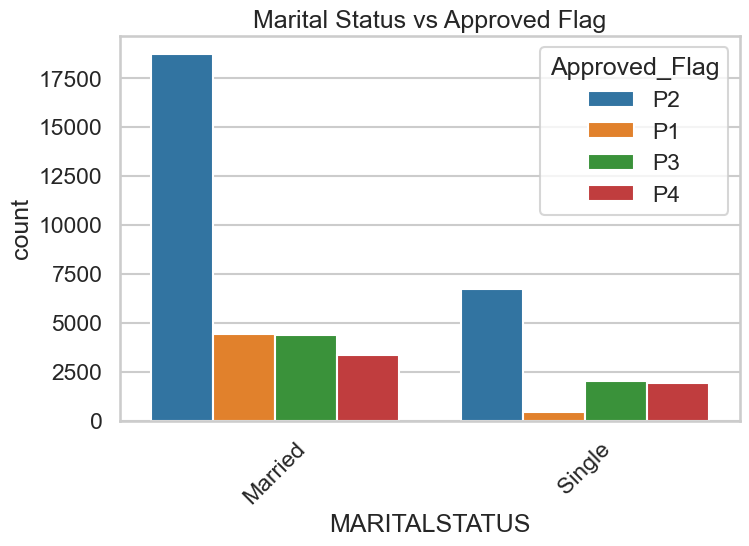

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="MARITALSTATUS", hue="Approved_Flag", data=df_final)
plt.xticks(rotation=45)
plt.title("Marital Status vs Approved Flag")
plt.show()

# Feature Selection

# chi-square

In [35]:
alpha = 0.05

for col in df_final.select_dtypes(include='object').columns[:-1]:
    chi2, pval, _, _ = chi2_contingency(
        pd.crosstab(df_final[col], df_final["Approved_Flag"])
    )
    
    if pval < alpha:
        decision = "Reject H0 (Significant association)"
    else:
        decision = "Fail to Reject H0 (No significant association)"
    
    print(f"{col}, P-value: {pval:.3e}, Decision: {decision}")
selected_categorical_features = df_final.select_dtypes(include="object").columns.tolist()


MARITALSTATUS, P-value: 3.578e-233, Decision: Reject H0 (Significant association)
EDUCATION, P-value: 2.694e-30, Decision: Reject H0 (Significant association)
GENDER, P-value: 1.908e-05, Decision: Reject H0 (Significant association)
last_prod_enq2, P-value: 0.000e+00, Decision: Reject H0 (Significant association)
first_prod_enq2, P-value: 7.850e-287, Decision: Reject H0 (Significant association)


since all the columns p-value is greater than significant level we accept all the above columns

# Anova

In [36]:
from scipy.stats import f_oneway

num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns
columns_to_be_kept_numerical = []
alpha = 0.05

for col in num_cols:
    groups = [
        group[col].dropna().values
        for _, group in df_final.groupby("Approved_Flag")
    ]
    
    # skip if not enough data
    if sum(len(g) > 0 for g in groups) < 2:
        continue
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"{col} → P-value: {p_value:.3e}")
    
    if p_value < alpha:
        columns_to_be_kept_numerical.append(col)

print("\nSelected numerical features:")
print(columns_to_be_kept_numerical)


PROSPECTID → P-value: 4.217e-02
Total_TL → P-value: 0.000e+00
Tot_Closed_TL → P-value: 0.000e+00
Tot_Active_TL → P-value: 1.635e-277
Total_TL_opened_L6M → P-value: 2.106e-210
Tot_TL_closed_L6M → P-value: 1.560e-44
pct_tl_open_L6M → P-value: 0.000e+00
pct_tl_closed_L6M → P-value: 2.676e-52
pct_active_tl → P-value: 1.501e-270
pct_closed_tl → P-value: 1.501e-270
Total_TL_opened_L12M → P-value: 1.486e-132
Tot_TL_closed_L12M → P-value: 1.763e-99
pct_tl_open_L12M → P-value: 0.000e+00
pct_tl_closed_L12M → P-value: 4.138e-49
Tot_Missed_Pmnt → P-value: 9.572e-210
Auto_TL → P-value: 9.310e-291
CC_TL → P-value: 5.710e-57
Consumer_TL → P-value: 8.413e-36
Gold_TL → P-value: 3.152e-170
Home_TL → P-value: 0.000e+00
PL_TL → P-value: 7.992e-235
Secured_TL → P-value: 0.000e+00
Unsecured_TL → P-value: 2.102e-118
Other_TL → P-value: 0.000e+00
Age_Oldest_TL → P-value: 0.000e+00
Age_Newest_TL → P-value: 1.047e-88
time_since_recent_payment → P-value: 8.944e-81
num_times_delinquent → P-value: 2.490e-77
max_re

In [37]:
final_features = selected_categorical_features + columns_to_be_kept_numerical
df_selected = df_final[final_features + ["Approved_Flag"]]
df_selected.head()

,MARITALSTATUS,EDUCATION,GENDER,last_prod_enq2,first_prod_enq2,Approved_Flag,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,...,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score,Approved_Flag
0,Married,12TH,M,PL,PL,P2,1,5,4,1,...,0,1,0.0,0.0,0.000,0.0,1,0,696,P2
1,Single,GRADUATE,F,ConsumerLoan,ConsumerLoan,P2,2,1,0,1,...,0,0,0.0,0.0,0.000,0.0,0,0,685,P2
2,Married,SSC,M,ConsumerLoan,others,P2,3,8,0,8,...,0,0,0.0,0.0,0.000,0.0,1,0,693,P2
3,Married,POST-GRADUATE,M,AL,AL,P1,5,3,2,1,...,0,0,0.0,0.0,0.000,0.0,0,0,753,P1
4,Married,12TH,M,ConsumerLoan,PL,P3,6,6,5,1,...,0,0,1.0,0.0,0.429,0.0,1,0,668,P3


In [38]:
print(len(final_features))


76


In [39]:
import pandas as pd
import numpy as np

# Only numerical features (from your ANOVA step)
num_df = df_final[columns_to_be_kept_numerical]

# Correlation matrix
corr_matrix = num_df.corr().abs()

# Upper triangle (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation > 0.8
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

print("Highly correlated columns to drop:")
print(to_drop)


Highly correlated columns to drop:
['Tot_Closed_TL', 'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'Gold_TL', 'Secured_TL', 'Unsecured_TL', 'num_deliq_12mts', 'num_deliq_6_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std_6mts', 'num_std_12mts', 'num_dbt_12mts', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'enq_L12m', 'enq_L6m', 'enq_L3m', 'pct_of_active_TLs_ever', 'pct_opened_TLs_L6m_of_L12m', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'GL_Flag']


In [40]:
columns_to_be_kept_numerical = [
    col for col in columns_to_be_kept_numerical if col not in to_drop
]


In [41]:
final_features = selected_categorical_features + columns_to_be_kept_numerical
print("Final feature count:", len(final_features))


Final feature count: 51


In [42]:
X = df_final[final_features]
y = df_final["Approved_Flag"]


# VIF (variance_inflation_factor)

In [43]:
# VIF for numerical columns
# numeric_columns = []
# for i in df.columns:
#     if df[i].dtype != 'object' and i not in ['PROSPECTID','Approved_Flag']:
#         numeric_columns.append(i)

In [44]:
# VIF sequentially check

# vif_data = df[numeric_columns]
# total_columns = vif_data.shape[1]
# columns_to_be_kept = []
# column_index = 0

In [45]:
# for i in range (0,total_columns):
    
#     vif_value = variance_inflation_factor(vif_data, column_index)
#     print (column_index,'---',vif_value)
    
    
#     if vif_value <= 6:
#         columns_to_be_kept.append( numeric_columns[i] )
#         column_index = column_index+1
    
#     else:
#         vif_data = vif_data.drop([ numeric_columns[i] ] , axis=1)

# Anova

In [46]:
# columns_to_be_kept_numerical = []

# for i in columns_to_be_kept:
#     a = list(df_final[i])  
#     b = list(df_final['Approved_Flag'])  
    
#     group_P1 = [value for value, group in zip(a, b) if group == 'P1']
#     group_P2 = [value for value, group in zip(a, b) if group == 'P2']
#     group_P3 = [value for value, group in zip(a, b) if group == 'P3']
#     group_P4 = [value for value, group in zip(a, b) if group == 'P4']


#     f_statistic, p_value = f_oneway(group_P1, group_P2, group_P3, group_P4)

#     if p_value <= 0.05:
#         columns_to_be_kept_numerical.append(i)

In [47]:
# listing all the final features
# features = columns_to_be_kept_numerical + ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
# df_final1 = df_final[features + ['Approved_Flag']]


In [48]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 79 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROSPECTID                  42064 non-null  int64  
 1   Total_TL                    42064 non-null  int64  
 2   Tot_Closed_TL               42064 non-null  int64  
 3   Tot_Active_TL               42064 non-null  int64  
 4   Total_TL_opened_L6M         42064 non-null  int64  
 5   Tot_TL_closed_L6M           42064 non-null  int64  
 6   pct_tl_open_L6M             42064 non-null  float64
 7   pct_tl_closed_L6M           42064 non-null  float64
 8   pct_active_tl               42064 non-null  float64
 9   pct_closed_tl               42064 non-null  float64
 10  Total_TL_opened_L12M        42064 non-null  int64  
 11  Tot_TL_closed_L12M          42064 non-null  int64  
 12  pct_tl_open_L12M            42064 non-null  float64
 13  pct_tl_closed_L12M          420

these are the final feature for model building 

# Encoding

In [49]:
X.loc[X['EDUCATION'] == 'SSC',['EDUCATION']]              = 1
X.loc[X['EDUCATION'] == '12TH',['EDUCATION']]             = 2
X.loc[X['EDUCATION'] == 'GRADUATE',['EDUCATION']]         = 3
X.loc[X['EDUCATION'] == 'UNDER GRADUATE',['EDUCATION']]   = 3
X.loc[X['EDUCATION'] == 'POST-GRADUATE',['EDUCATION']]    = 4
X.loc[X['EDUCATION'] == 'OTHERS',['EDUCATION']]           = 1
X.loc[X['EDUCATION'] == 'PROFESSIONAL',['EDUCATION']]     = 3
X['EDUCATION'] = X['EDUCATION'].astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_16348\1894506203.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['EDUCATION'] = X['EDUCATION'].astype(int)


In [50]:
X['EDUCATION'] = X['EDUCATION'].astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 51 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MARITALSTATUS              42064 non-null  object 
 1   EDUCATION                  42064 non-null  int64  
 2   GENDER                     42064 non-null  object 
 3   last_prod_enq2             42064 non-null  object 
 4   first_prod_enq2            42064 non-null  object 
 5   Approved_Flag              42064 non-null  object 
 6   PROSPECTID                 42064 non-null  int64  
 7   Total_TL                   42064 non-null  int64  
 8   Tot_Active_TL              42064 non-null  int64  
 9   Total_TL_opened_L6M        42064 non-null  int64  
 10  Tot_TL_closed_L6M          42064 non-null  int64  
 11  pct_tl_open_L6M            42064 non-null  float64
 12  pct_tl_closed_L6M          42064 non-null  float64
 13  pct_active_tl              42064 non-null  flo

C:\Users\User\AppData\Local\Temp\ipykernel_16348\3842094716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['EDUCATION'] = X['EDUCATION'].astype(int)


In [51]:
df_final.select_dtypes(include='object').columns.tolist()

['MARITALSTATUS',
 'EDUCATION',
 'GENDER',
 'last_prod_enq2',
 'first_prod_enq2',
 'Approved_Flag']

In [52]:

cols = ['MARITALSTATUS', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']

oh = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded = oh.fit_transform(X[cols])
encoded_cols = oh.get_feature_names_out(cols)


encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=X.index)

X = X.drop(columns=cols)
X = pd.concat([X, encoded_df], axis=1)



In [53]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


In [54]:
X.drop(columns=['PROSPECTID', 'Approved_Flag'], inplace=True)

In [55]:
y

array([1, 1, 1, ..., 2, 1, 1], shape=(42064,))

In [56]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(25))


                      Feature  Importance
44               Credit_Score    0.575109
17              Age_Oldest_TL    0.061097
35      time_since_recent_enq    0.049410
23                    num_std    0.030904
30                    tot_enq    0.020466
41     pct_PL_enq_L6m_of_L12m    0.020225
34                 PL_enq_L6m    0.018183
21  max_recent_level_of_deliq    0.017000
20       num_times_delinquent    0.014876
19  time_since_recent_payment    0.013896
36                        AGE    0.012993
38        Time_With_Curr_Empr    0.012193
1                    Total_TL    0.012052
18              Age_Newest_TL    0.010908
37           NETMONTHLYINCOME    0.010444
8            pct_tl_open_L12M    0.009773
7               pct_active_tl    0.009349
33                     PL_enq    0.007548
2               Tot_Active_TL    0.006977
16                   Other_TL    0.006652
5             pct_tl_open_L6M    0.006465
9          pct_tl_closed_L12M    0.005274
13                Consumer_TL    0

In [57]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





In [58]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Step 1: SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_train, y_train)


model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1,
    eval_metric="mlogloss",
    early_stopping_rounds=50,   
    random_state=42
)

# Step 3: Train (NO callbacks, NO early_stopping here)
model.fit(
    X_res, y_res,
    eval_set=[(x_test, y_test)],
    verbose=True
)

[0]	validation_0-mlogloss:1.32954
[1]	validation_0-mlogloss:1.28147
[2]	validation_0-mlogloss:1.23115
[3]	validation_0-mlogloss:1.18385
[4]	validation_0-mlogloss:1.14601
[5]	validation_0-mlogloss:1.10990
[6]	validation_0-mlogloss:1.08802
[7]	validation_0-mlogloss:1.06071
[8]	validation_0-mlogloss:1.02231
[9]	validation_0-mlogloss:0.99608
[10]	validation_0-mlogloss:0.96113
[11]	validation_0-mlogloss:0.93070
[12]	validation_0-mlogloss:0.91021
[13]	validation_0-mlogloss:0.87907
[14]	validation_0-mlogloss:0.85404
[15]	validation_0-mlogloss:0.82814
[16]	validation_0-mlogloss:0.81524
[17]	validation_0-mlogloss:0.79084
[18]	validation_0-mlogloss:0.76738
[19]	validation_0-mlogloss:0.74240
[20]	validation_0-mlogloss:0.72506
[21]	validation_0-mlogloss:0.70848
[22]	validation_0-mlogloss:0.68795
[23]	validation_0-mlogloss:0.66949
[24]	validation_0-mlogloss:0.64847
[25]	validation_0-mlogloss:0.62839
[26]	validation_0-mlogloss:0.61442
[27]	validation_0-mlogloss:0.59550
[28]	validation_0-mlogloss:0.5

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [59]:
X_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81628 entries, 0 to 81627
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EDUCATION                     81628 non-null  int64  
 1   Total_TL                      81628 non-null  int64  
 2   Tot_Active_TL                 81628 non-null  int64  
 3   Total_TL_opened_L6M           81628 non-null  int64  
 4   Tot_TL_closed_L6M             81628 non-null  int64  
 5   pct_tl_open_L6M               81628 non-null  float64
 6   pct_tl_closed_L6M             81628 non-null  float64
 7   pct_active_tl                 81628 non-null  float64
 8   pct_tl_open_L12M              81628 non-null  float64
 9   pct_tl_closed_L12M            81628 non-null  float64
 10  Tot_Missed_Pmnt               81628 non-null  int64  
 11  Auto_TL                       81628 non-null  int64  
 12  CC_TL                         81628 non-null  int64  
 13  C

In [60]:
from sklearn.metrics import classification_report
X_test_leak = X.drop(columns=["Credit_Score"])

X_train, X_test, y_train, y_test = train_test_split(
    X_test_leak, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print(classification_report(y_test, y_pred))


y_train_pred = model.predict(X_train)

print("TRAINING PERFORMANCE:\n")
print(classification_report(y_train, y_train_pred))



ValueError: Must have at least 1 validation dataset for early stopping.

In [ ]:
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)

selector = SelectFromModel(xgb_model, threshold="median")  
# keeps top 50%

X_train_sel = selector.transform(x_train)
X_test_sel = selector.transform(x_test)

selected_features = x_train.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['EDUCATION', 'Total_TL', 'Total_TL_opened_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Home_TL', 'PL_TL', 'Age_Oldest_TL',
       'time_since_recent_payment', 'num_times_delinquent',
       'max_recent_level_of_deliq', 'tot_enq', 'CC_enq', 'PL_enq_L6m',
       'time_since_recent_enq', 'Time_With_Curr_Empr',
       'pct_CC_enq_L6m_of_L12m', 'Credit_Score', 'MARITALSTATUS_Single',
       'GENDER_M', 'last_prod_enq2_ConsumerLoan',
       'first_prod_enq2_ConsumerLoan', 'first_prod_enq2_HL',
       'first_prod_enq2_PL', 'first_prod_enq2_others'],
      dtype='object')


e:\credit_risk_modeling\shani67\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
e:\credit_risk_modeling\shani67\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
# Drop ID / leakage columns
X_train = X_train.drop(columns=['PROSPECTID'], errors='ignore')
X_test = X_test.drop(columns=['PROSPECTID'], errors='ignore')


In [ ]:
from imblearn.combine import SMOTETomek

# sm = SMOTETomek(random_state=42)
# X_res, y_res = sm.fit_resample(x_train, y_train)

# perfect pipeline

In [70]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

# ================================
# STEP 1: Split data
# ================================
X_features =X.drop(columns=["Credit_Score"])
y_target = y

x_train, x_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

# ================================
# STEP 2: Feature Importance (Random Forest)
# ================================
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 20 Features:\n")
print(feature_importance_df.head(30))

# ================================
# STEP 3: SMOTE + Tomek Resampling
# ================================
sm = SMOTETomek(random_state=42)
X_res, y_res = sm.fit_resample(x_train, y_train)

print(f"\nResampled class distribution:")
print(pd.Series(y_res).value_counts().sort_index())

# ================================
# STEP 4: Train XGBoost (with eval_metric / early stopping in constructor)
# ================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1,
    objective="multi:softprob",  # multiclass probability output
    eval_metric="mlogloss",      # evaluation metric (XGBoost 3.2+)
    early_stopping_rounds=50,    # early stopping rounds
    random_state=42
)

# Fit with eval_set only (no eval_metric / early_stopping_rounds in fit)
model.fit(
    X_res, y_res,
    eval_set=[(x_train, y_train), (x_test, y_test)],
    verbose=50
)

print("\nBest Iteration:", model.best_iteration)

# ================================
# Helper: Custom threshold prediction for class 2
# ================================
def predict_with_threshold(probs, threshold):
    """Overwrite predictions to class 2 whenever its prob > threshold."""
    preds = np.argmax(probs, axis=1)
    mask = probs[:, 2] > threshold
    preds[mask] = 2
    return preds

# ================================
# STEP 5: Threshold Tuning for Class 2
# ================================
y_probs = model.predict_proba(x_test)

print("\n" + "="*70)
print("THRESHOLD TUNING FOR CLASS 2")
print("="*70)

results = []
best_f1_c2 = 0.0
best_t = 0.25  # default

# Choose a reasonable range around your current best (0.25)
thresholds = np.arange(0.15, 0.75, 0.025)

for t in thresholds:
    preds = predict_with_threshold(y_probs, t)

    f1_c2 = f1_score(y_test, preds, average=None, zero_division=0)[2]
    acc = accuracy_score(y_test, preds)

    results.append({
        "threshold": t,
        "class2_f1": f1_c2,
        "accuracy": acc
    })

    if f1_c2 > best_f1_c2:
        best_f1_c2 = f1_c2
        best_t = t

results_df = pd.DataFrame(results)

print("\nTop 10 thresholds for Class 2 (by F1):")
print(results_df.nlargest(10, "class2_f1"))

print(f"\nBest Threshold for Class 2 (max F1): {best_t:.3f}")
print(f"Corresponding Class 2 F1: {best_f1_c2:.3f}")

# ================================
# STEP 6: Final Test Evaluation
# ================================
final_preds = predict_with_threshold(y_probs, best_t)

print("\n" + "="*60)
print("FINAL TEST PERFORMANCE (Balanced):")
print("="*60)
print(classification_report(y_test, final_preds, target_names=["0", "1", "2", "3"]))

# ================================
# STEP 7: Training Evaluation (with same threshold)
# ================================
y_train_probs = model.predict_proba(x_train)
train_preds = predict_with_threshold(y_train_probs, best_t)

print("\n" + "="*60)
print("TRAINING PERFORMANCE (Balanced):")
print("="*60)
print(classification_report(y_train, train_preds, target_names=["0", "1", "2", "3"]))

Top 20 Features:

                        Feature  Importance
17                Age_Oldest_TL    0.119065
35        time_since_recent_enq    0.098992
23                      num_std    0.057694
19    time_since_recent_payment    0.046611
30                      tot_enq    0.043443
38          Time_With_Curr_Empr    0.042596
36                          AGE    0.040115
37             NETMONTHLYINCOME    0.037451
21    max_recent_level_of_deliq    0.036411
18                Age_Newest_TL    0.035035
20         num_times_delinquent    0.029987
41       pct_PL_enq_L6m_of_L12m    0.029130
34                   PL_enq_L6m    0.028587
1                      Total_TL    0.027531
8              pct_tl_open_L12M    0.023713
7                 pct_active_tl    0.022534
2                 Tot_Active_TL    0.018153
33                       PL_enq    0.017816
16                     Other_TL    0.016997
5               pct_tl_open_L6M    0.016788
0                     EDUCATION    0.015877
13            

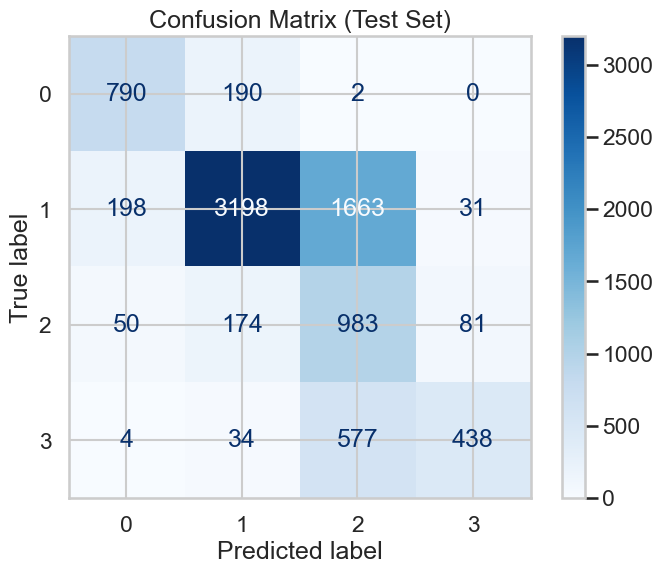

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate Confusion Matrix for Test Set
cm = confusion_matrix(y_test, final_preds)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1", "2", "3"])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title("Confusion Matrix (Test Set)")
plt.show()

In [65]:
import joblib

# FINAL PRODUCTION MODEL
PRODUCTION_MODEL = {
    'model': model,
    'threshold': 0.20,  # Max Class 2 F1
    'features': x_test.columns.tolist()
}

# SAVE
joblib.dump(PRODUCTION_MODEL, 'credit_model_PROD.pkl')

# PRODUCTION PREDICTOR
def predict_credit_risk(X_new):
    probs = model.predict_proba(X_new)
    preds = predict_with_threshold(probs, 0.20)
    return preds, probs[:, 2]  # Class 2 probabilities

print("✅ PRODUCTION READY - Model saved!")

✅ PRODUCTION READY - Model saved!


# CV SUMMARY

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np


n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

cv_results = []
all_class2_f1 = []

print("\n" + "="*80)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*80)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_features, y_target)):
    # FIXED: Use [] for numpy arrays, .iloc for DataFrames
    X_fold_train, X_fold_val = X_features.iloc[train_idx], X_features.iloc[val_idx]
    y_fold_train, y_fold_val = y_target[train_idx], y_target[val_idx]  # ← FIXED
    
    # SMOTE only on TRAINING fold
    sm = SMOTETomek(random_state=42)
    X_res, y_res = sm.fit_resample(X_fold_train, y_fold_train)
    
    # Train model
    fold_model = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, gamma=1,
        reg_alpha=0.5, reg_lambda=1,
        eval_metric="mlogloss", early_stopping_rounds=50,
        random_state=42
    )
    
    fold_model.fit(
        X_res, y_res,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    # Use your best threshold (0.20)
    fold_probs = fold_model.predict_proba(X_fold_val)
    fold_preds = predict_with_threshold(fold_probs, 0.20)
    
    fold_f1_c2 = f1_score(y_fold_val, fold_preds, average=None, zero_division=0)[2]
    fold_acc = accuracy_score(y_fold_val, fold_preds)
    
    cv_results.append({
        'fold': fold+1,
        'class2_f1': fold_f1_c2,
        'accuracy': fold_acc
    })
    all_class2_f1.append(fold_f1_c2)
    
    print(f"Fold {fold+1}: Class2 F1={fold_f1_c2:.3f}, Acc={fold_acc:.3f}")


cv_df = pd.DataFrame(cv_results)
print("\n" + "="*50)
print("CROSS-VALIDATION SUMMARY")
print("="*50)
print(cv_df)
print(f"\nMEAN Class 2 F1: {np.mean(all_class2_f1):.3f} ± {np.std(all_class2_f1):.3f}")
print(f"MEAN Accuracy:   {cv_df['accuracy'].mean():.3f} ± {cv_df['accuracy'].std():.3f}")

print(f"\nSingle Split: Class2 F1={best_f1_c2:.3f}")
print("✅ PASS - Stable model" if abs(np.mean(all_class2_f1) - best_f1_c2) < 0.05 else "❌ FAIL - Retrain needed")


5-FOLD STRATIFIED CROSS-VALIDATION
Fold 1: Class2 F1=0.434, Acc=0.644
Fold 2: Class2 F1=0.436, Acc=0.645
Fold 3: Class2 F1=0.445, Acc=0.652
Fold 4: Class2 F1=0.450, Acc=0.649
Fold 5: Class2 F1=0.441, Acc=0.650

CROSS-VALIDATION SUMMARY
   fold  class2_f1  accuracy
0     1   0.433724  0.644479
1     2   0.436127  0.644598
2     3   0.445495  0.651729
3     4   0.450292  0.648520
4     5   0.440981  0.649548

MEAN Class 2 F1: 0.441 ± 0.006
MEAN Accuracy:   0.648 ± 0.003

Single Split: Class2 F1=0.436
✅ PASS - Stable model


# ROC Curve/# PR Curve


CLASS 2 DIAGNOSTIC METRICS
ROC-AUC:        0.778
PR-AUC:         0.345
Baseline F1:    0.436
Optimal thresh: 0.200


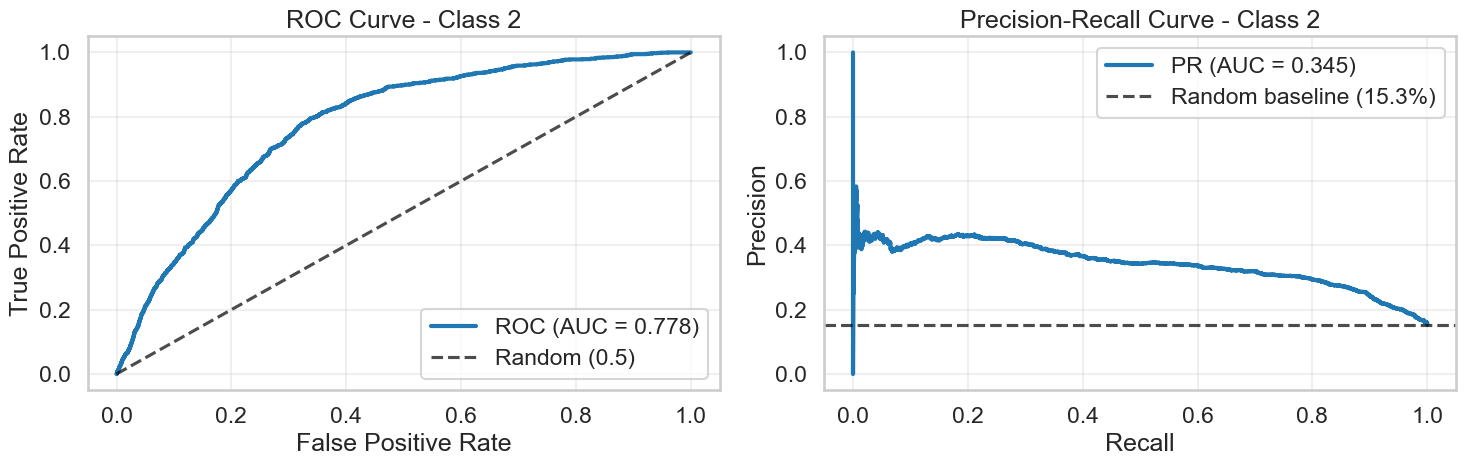


PR Curve Optimal Threshold: 0.230
PR Curve Peak F1:          0.440


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


y_test_binary = (y_test == 2).astype(int)  # Class 2 vs rest
y_probs_c2 = y_probs[:, 2]  # Class 2 probabilities

# ROC Curve + AUC
fpr, tpr, roc_thresholds = roc_curve(y_test_binary, y_probs_c2)
roc_auc = auc(fpr, tpr)

# PR Curve + AUC (BETTER for imbalance)
precision, recall, pr_thresholds = precision_recall_curve(y_test_binary, y_probs_c2)
pr_auc = average_precision_score(y_test_binary, y_probs_c2)

print("\n" + "="*60)
print("CLASS 2 DIAGNOSTIC METRICS")
print("="*60)
print(f"ROC-AUC:        {roc_auc:.3f}")
print(f"PR-AUC:         {pr_auc:.3f}")
print(f"Baseline F1:    {best_f1_c2:.3f}")
print(f"Optimal thresh: {best_t:.3f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(fpr, tpr, linewidth=3, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0,1], [0,1], 'k--', alpha=0.7, label='Random (0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - Class 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PR Curve
ax2.plot(recall, precision, linewidth=3, label=f'PR (AUC = {pr_auc:.3f})')
ax2.axhline(y=np.mean(y_test_binary), color='k', linestyle='--', alpha=0.7, 
           label=f'Random baseline ({np.mean(y_test_binary):.1%})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve - Class 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pr_f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_pr_idx = np.argmax(pr_f1_scores)
best_pr_thresh = pr_thresholds[best_pr_idx]

print(f"\nPR Curve Optimal Threshold: {best_pr_thresh:.3f}")
print(f"PR Curve Peak F1:          {pr_f1_scores[best_pr_idx]:.3f}")

In [2]:
import pandas as pd
df=pd.read_csv(r"E:\credit_risk_modeling\artifacts\test_processed.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age_Oldest_TL                 10262 non-null  float64
 1   enq_L3m                       10262 non-null  float64
 2   time_since_recent_enq         10262 non-null  float64
 3   enq_L6m                       10262 non-null  float64
 4   num_std                       10262 non-null  float64
 5   num_std_12mts                 10262 non-null  float64
 6   Time_With_Curr_Empr           10262 non-null  float64
 7   time_since_recent_payment     10262 non-null  float64
 8   AGE                           10262 non-null  float64
 9   enq_L12m                      10262 non-null  float64
 10  NETMONTHLYINCOME              10262 non-null  float64
 11  Age_Newest_TL                 10262 non-null  float64
 12  pct_currentBal_all_TL         10262 non-null  float64
 13  n

In [ ]:
df